In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
import pickle

In [2]:
df = pd.read_csv("student_survey.csv")
df.head(5)

,Timestamp,Registration Number,Email,Job role that you are interested in\n,What is the minimum salary of students placed through campus (In LPA..respond as a number),What is the maximum salary of students placed through campus (In LPA..respond as a number),What is the median salary of students placed through campus (In LPA..respond as a number),Which is the highest paying company,Rate your contribution towards extra curricular activities,Rate your technical competencies,What are your package expectations (LPA),your CIA % of last semester,your GPA of last semester,Your maximum attendance % till last semester,Internships Interests
0,6/22/2026 8:49:31,2547123,jiyaelza.jabi@mca.christuniversity.in,Software Engineer,4,Option 1,9,Deolite,2,2,7,78,3.24,Option 1,Industry
1,6/22/2026 8:49:50,2547122,jinishaleema.rosario@mca.christuniversity.in,Data Engineer,"7,00,000",Option 1,"4,50,000",Deolite,4,3,"6,00,000",64.78,3.2,Option 1,Industry
2,6/22/2026 8:50:44,2547101,rajeev.chandar@mca.christuniversity.in,Software Engineer,6,17,8,DE Shaw,5,5,13,80,3.6,Option 1,Industry
3,6/22/2026 8:51:00,2547156,sounak.chakraborty@mca.christuniversity.in,Data Scientist,4.5,12,6.9,DE Shaw,3,4,7,70,3.2,92,Industry
4,6/22/2026 8:51:42,2547148,samar.subhash@mca.christuniversity.in,Software Engineer,8,12,10,EY,5,3,10,68,3.4,85,Industry


In [3]:
print(df.shape)

print(df.isnull().sum())

df = df.drop_duplicates(
    subset=['Registration Number '],
    keep='last'
)

df.rename(columns={
    'your CIA % of last semester ':'CIA',
    'your GPA of last semester':'GPA',
    'Your maximum attendance % till last semester':'Attendance'
}, inplace=True)

(54, 15)
Timestamp                                                                                     0
Registration Number                                                                           0
Email                                                                                         0
Job role that you are interested in\n                                                         0
What is the minimum salary of students placed through campus (In LPA..respond as a number)    0
What is the maximum salary of students placed through campus (In LPA..respond as a number)    0
What is the  median salary of students placed through campus (In LPA..respond as a number)    0
Which is the highest paying company                                                           0
Rate your contribution towards extra curricular activities                                    0
Rate your technical competencies                                                              0
What are your package expectati

In [4]:
df.head(10)

,Timestamp,Registration Number,Email,Job role that you are interested in\n,What is the minimum salary of students placed through campus (In LPA..respond as a number),What is the maximum salary of students placed through campus (In LPA..respond as a number),What is the median salary of students placed through campus (In LPA..respond as a number),Which is the highest paying company,Rate your contribution towards extra curricular activities,Rate your technical competencies,What are your package expectations (LPA),CIA,GPA,Attendance,Internships Interests
2,6/22/2026 8:50:44,2547101,rajeev.chandar@mca.christuniversity.in,Software Engineer,6,17,8,DE Shaw,5,5,13,80,3.6,Option 1,Industry
3,6/22/2026 8:51:00,2547156,sounak.chakraborty@mca.christuniversity.in,Data Scientist,4.5,12,6.9,DE Shaw,3,4,7,70,3.2,92,Industry
4,6/22/2026 8:51:42,2547148,samar.subhash@mca.christuniversity.in,Software Engineer,8,12,10,EY,5,3,10,68,3.4,85,Industry
5,6/22/2026 8:51:44,2547155,shubham.swaraj@mca.christuniversity.in,Software Engineer,4.5,Option 1,6,DE Shaw,3,4,9,70%,3.5,87%,Industry
6,6/22/2026 8:51:50,2547149,samuel.shine@mca.christuniversity.in,Data Scientist,3.4,Option 1,6,DE Shaw,3,4,13,88%,3.7,Option 1,Research
7,6/22/2026 8:51:57,2547115,arnav.narula@mca.christuniversity.in,Software Engineer,3,12,7,DE Shaw,3,4,10,3.45,10,90,Industry
8,6/22/2026 8:52:00,2547147,sp.sooryananda@mca.christuniversity.in,Business Analyst,3,8,5,DE Shaw,4,3,5,70,3.4,89,Industry
9,6/22/2026 8:52:06,2547105,achindra.sharma@mca.christuniversity.in,Software Engineer,4.5,12,6,DE Shaw,2,4,12,83,3.89,98,Industry
10,6/22/2026 8:52:08,2547113,arjit.singhal@mca.christuniversity.in,Software Engineer,3.3,12,6.3,DE Shaw,2,3,6,70,3.3,97,Industry
11,6/22/2026 8:52:13,2547145,renoreji.matthew@mca.christuniversity.in,Software Engineer,"5,00,000.00","12,00,000.00","8,50,000.00",DE Shaw,3,3,10 LPA,70%,3.5,99%,Industry


In [5]:
def clean_numeric(value):

    if pd.isna(value):
        return np.nan

    value = str(value).strip()

    value = value.replace('%','')
    value = value.replace('LPA','')
    value = value.replace('lpa','')

    if value in ['Option 1','na','NA','-','']:
        return np.nan

    try:
        return float(value)
    except:
        return np.nan
    
df['CIA'] = df['CIA'].apply(clean_numeric)
df['GPA'] = df['GPA'].apply(clean_numeric)
df['Attendance'] = df['Attendance'].apply(clean_numeric)
df['CIA'] = pd.to_numeric(df['CIA'], errors='coerce')
df['GPA'] = pd.to_numeric(df['GPA'], errors='coerce')
df['Attendance'] = pd.to_numeric(df['Attendance'], errors='coerce')
print(df[['CIA','GPA','Attendance']].dtypes)

CIA           float64
GPA           float64
Attendance    float64
dtype: object


In [6]:
df.describe()

,Rate your contribution towards extra curricular activities,Rate your technical competencies,CIA,GPA,Attendance
count,52.000000,52.000000,51.000000,51.000000,48.000000
mean,3.615385,3.442308,71.399608,5.396078,93.121458
std,0.973247,0.826366,15.228290,12.135120,4.807110
min,2.000000,1.000000,3.450000,2.900000,85.000000
25%,3.000000,3.000000,70.000000,3.400000,89.000000
50%,4.000000,3.000000,71.000000,3.500000,93.500000
75%,4.000000,4.000000,79.665000,3.700000,97.992500
max,5.000000,5.000000,89.000000,90.000000,100.000000


In [7]:
df = df[(df['GPA'] >= 0) & (df['GPA'] <= 4)]
df = df[['CIA','Attendance','GPA']].dropna()

In [8]:
df.head(10)

,CIA,Attendance,GPA
3,70.00,92.0,3.20
4,68.00,85.0,3.40
5,70.00,87.0,3.50
8,70.00,89.0,3.40
9,83.00,98.0,3.89
10,70.00,97.0,3.30
11,70.00,99.0,3.50
12,70.00,97.0,3.48
13,64.67,95.0,3.40
14,70.00,90.0,2.90


In [9]:
print(df.describe())

             CIA  Attendance        GPA
count  43.000000   43.000000  43.000000
mean   71.626279   93.833256   3.509302
std    12.126630    4.511739   0.255244
min     4.000000   85.000000   2.900000
25%    70.000000   90.000000   3.400000
50%    71.000000   95.000000   3.500000
75%    78.000000   98.000000   3.655000
max    89.000000  100.000000   4.000000


In [23]:
X = df[['CIA']]
y = df['GPA']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()

model.fit(X_train,y_train)

slope = model.coef_[0]
intercept = model.intercept_

print("Slope:",slope)
print("Intercept:",intercept)

pred_sklearn = model.predict(X_test)

print(pred_sklearn[:5])

Slope: 0.014013742914895464
Intercept: 2.477183720943282
[2.53323869 3.59828315 3.52821444 3.48617321 3.52821444]


percentage to numeric
90% attendace becomes 0.9
cia marks also convert to fraction

CIA to GPA
R² Score: 0.15433322926896198


c:\Users\shree\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


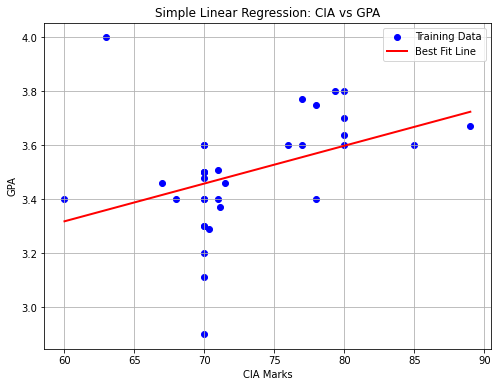

In [25]:
train_pred_sklearn = model.predict(X_train)
r2 = r2_score(y_train, train_pred_sklearn)
print("CIA to GPA")
print("R² Score:", r2)

plt.figure(figsize=(8,6))
plt.scatter(X_train, y_train, color='blue', label='Training Data')

x_line = np.linspace(X_train.min(), X_train.max(), 100)
y_line = model.predict(x_line)

plt.plot(x_line, y_line, color='red', linewidth=2, label='Best Fit Line')

plt.xlabel("CIA Marks")
plt.ylabel("GPA")
plt.title("Simple Linear Regression: CIA vs GPA")
plt.legend()
plt.grid(True)
plt.show()

Manual CIA to GPA

In [13]:
def slope_intercept(x_series, y_series):
    n = len(x_series)
    x_mean = sum(x_series) / n
    y_mean = sum(y_series) / n
    num=0
    denom=0
    for i in range(n):
        num += (x_series[i] - x_mean) * (y_series[i] - y_mean)
    for i in range(n):
        denom += (x_series[i] - x_mean) ** 2
    m = num / denom
    b = y_mean - m * x_mean

    return m, b

def predict(x_value, m, b):
    return m * x_value + b

In [14]:
x = X_train['CIA'].values
y = y_train.values
m, b = slope_intercept(x, y)
print("Manually calculated slope: ", m, "  Manually calculated intercept: ", b)

pred_manual = m*X_test['CIA'] + b
print(pred_manual.head())

Manually calculated slope:  0.014013742914895464   Manually calculated intercept:  2.477183720943282
47    2.533239
31    3.598283
32    3.528214
46    3.486173
44    3.528214
Name: CIA, dtype: float64


In [15]:
comparison = pd.DataFrame({
    'Sklearn':pred_sklearn,
    'Manual':pred_manual
})

comparison['Difference'] = (
    comparison['Sklearn']
    - comparison['Manual']
)

print(comparison.head())

     Sklearn    Manual  Difference
47  2.533239  2.533239         0.0
31  3.598283  3.598283         0.0
32  3.528214  3.528214         0.0
46  3.486173  3.486173         0.0
44  3.528214  3.528214         0.0


In [16]:
X = df[['Attendance']]
y = df['GPA']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()

model.fit(X_train,y_train)

slope = model.coef_[0]
intercept = model.intercept_

print("Slope:",slope)
print("Intercept:",intercept)

pred_sklearn = model.predict(X_test)

print(pred_sklearn[:5])

Slope: 0.012851096392619837
Intercept: 2.297019504266432
[3.58212914 3.53072476 3.50502257 3.42791599 3.45361818]


c:\Users\shree\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


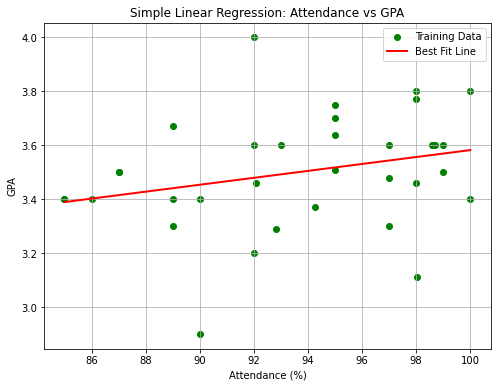

In [17]:
plt.figure(figsize=(8,6))
plt.scatter(X_train, y_train, color='green', label='Training Data')

x_line = np.linspace(X_train.min(), X_train.max(), 100)
y_line = model.predict(x_line)

plt.plot(x_line, y_line, color='red', linewidth=2, label='Best Fit Line')

plt.xlabel("Attendance (%)")
plt.ylabel("GPA")
plt.title("Simple Linear Regression: Attendance vs GPA")
plt.legend()
plt.grid(True)
plt.show()

Manual Attendance to GPA

In [18]:
x = X_train['Attendance'].values
y = y_train.values
m, b = slope_intercept(x, y)
print("Manually calculated slope: ", m, "  Manually calculated intercept: ", b)

pred_manual = m*X_test['Attendance'] + b
print(pred_manual.head())

Manually calculated slope:  0.01285109639261984   Manually calculated intercept:  2.297019504266432
47    3.582129
31    3.530725
32    3.505023
46    3.427916
44    3.453618
Name: Attendance, dtype: float64


In [19]:
comparison = pd.DataFrame({
    'Sklearn':pred_sklearn,
    'Manual':pred_manual
})

comparison['Difference'] = (
    comparison['Sklearn']
    - comparison['Manual']
)

print(comparison.head())
print(comparison['Difference'].abs().max())

     Sklearn    Manual    Difference
47  3.582129  3.582129 -4.440892e-16
31  3.530725  3.530725 -4.440892e-16
32  3.505023  3.505023 -4.440892e-16
46  3.427916  3.427916 -4.440892e-16
44  3.453618  3.453618 -4.440892e-16
8.881784197001252e-16


In [20]:
parameters = {
    'slope': slope,
    'intercept': intercept
}

with open(
    'linear_regression_weights.pkl',
    'wb'
) as f:

    pickle.dump(parameters,f)

print("Saved")

Saved


In [21]:
with open(
    'linear_regression_weights.pkl',
    'rb'
) as f:

    loaded = pickle.load(f)

print(loaded)

{'slope': 0.012851096392619837, 'intercept': 2.297019504266432}


In [22]:
new_cia = 80

prediction = (
    loaded['slope'] * new_cia
    + loaded['intercept']
)

print("Predicted GPA:",prediction)

Predicted GPA: 3.325107215676019


Interpretations:

CIA vs GPA
Positive linear relationship observed.
Students with higher CIA percentage generally tend to have higher GPA.
Scikit-learn and manual OLS produced almost identical slope and intercept values.


Attendance vs GPA
Weak to moderate positive relationship observed.
Attendance alone is not a strong predictor of GPA and does not really affect it.


Comparison
Predictions from Scikit-learn and manually computed OLS were nearly identical.
This confirms that Scikit-learn internally uses the same least squares principle.